In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder

In [3]:
estudiantes=pd.read_csv('../raw/dataset_estudiantes.csv')

estudiantes.head(5)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


### Observaciones iniciales del análisis exploratorio
- General: No hay duplicados
- **horas_sueno** ---> tiene nulos. 15% del total. Listo
- **tiene_tutor** ---> cambiar a 0 y 1. Listo
- **horario_estudio_preferido** ---> tiene nulos. 10% del total. Listo
- **estilo_aprendizaje** ---> tiene nulos. 5% del total- Listo

## Gestion de nulos

- Dos nulos en columnas categóricas, cambiar por Unknown.
- Horas de sueño, comprobar outliers y distribución para sustituir con media/mediana.

In [4]:
##Columnas categoría

value= 'Desconocido'
columnas_null_categorias=['horario_estudio_preferido','estilo_aprendizaje']
estudiantes[columnas_null_categorias]=estudiantes[columnas_null_categorias].fillna(value)

In [5]:
# Columna numérica: horas_sueno
estudiantes['horas_sueno'].describe().round(2)

count    850.00
mean       7.01
std        1.44
min        4.00
25%        6.00
50%        7.02
75%        8.02
max       10.00
Name: horas_sueno, dtype: float64

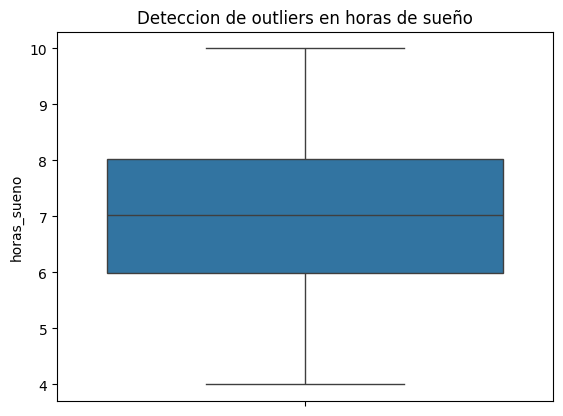

In [6]:
plt.figuresize=(8,5)
sns.boxplot(y=estudiantes['horas_sueno'])

plt.title ('Deteccion de outliers en horas de sueño')
plt.show()

#No se detectan outliers en el gráfico

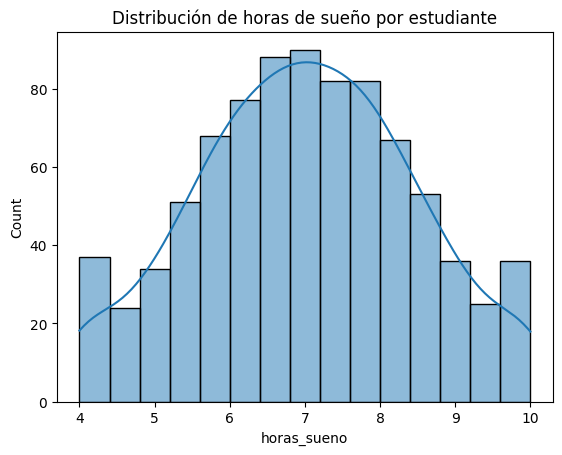

In [7]:
plt.figsize=(8.5)
sns.histplot (x=estudiantes['horas_sueno'] ,kde=True)

plt.title('Distribución de horas de sueño por estudiante')
plt.show()

In [8]:
#Sustituimos los nulos de esta columna por la media

estudiantes['horas_sueno']=estudiantes['horas_sueno'].fillna(estudiantes['horas_sueno'].mean())

In [9]:
estudiantes['horas_sueno'].isnull().sum()

np.int64(0)

### Comprobamos si queda algún nulo

In [10]:
estudiantes.isnull().sum()

horas_estudio_semanal        0
nota_anterior                0
tasa_asistencia              0
horas_sueno                  0
edad                         0
nivel_dificultad             0
tiene_tutor                  0
horario_estudio_preferido    0
estilo_aprendizaje           0
nota_final                   0
aprobado                     0
dtype: int64

## Gestion de outliers

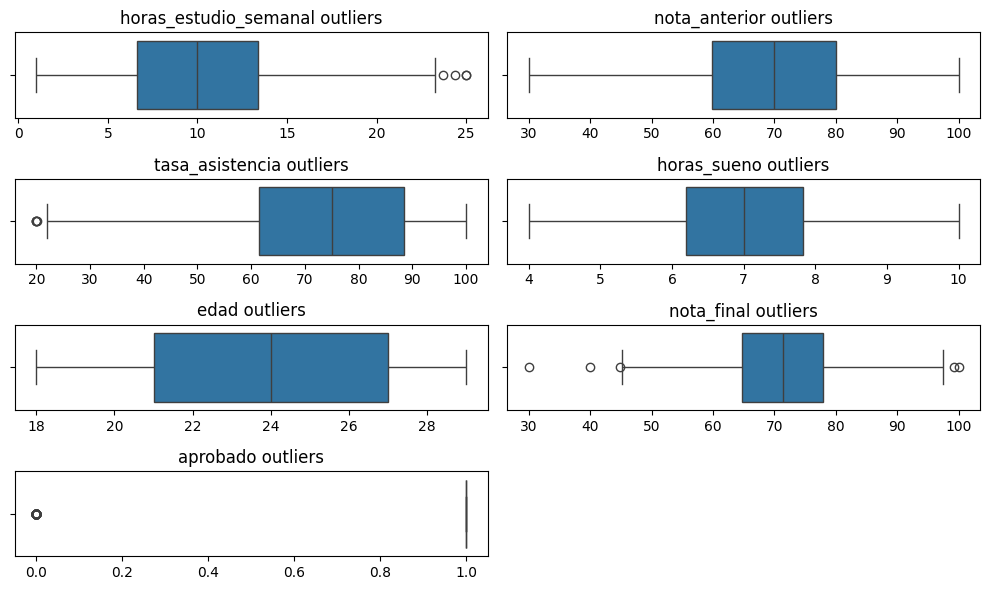

In [11]:
estudiantes_num= estudiantes.select_dtypes(include=np.number)
columnas_numericas=estudiantes_num.columns


# Cálculo de  gráficos y filas
n_plots = len(columnas_numericas)
num_rows = math.ceil(n_plots / 2)

# Ajustar el tamaño
width = 5 * 2
height = 1.5 * num_rows
size = (width, height)

# Crear la estructura de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=size)
axes = axes.flat

# Función de boxplot para cada variable:
for i, col in enumerate(columnas_numericas):
   sns.boxplot(
       x=col,
       data=estudiantes_num,
       ax=axes[i]
   )

   axes[i].set_title(f'{col} outliers')
   axes[i].set_xlabel('')

# Eliminar el último gráfico si sobra un espacio vacío
if n_plots % 2 != 0:
   fig.delaxes(axes[-1])


plt.tight_layout()
plt.show()

### Outliers con método IQR

In [12]:
# Diccionario para almacenar los outliers detectados en cada columna
outliers_dict_iqr = {}

for col in estudiantes_num.columns:
   Q1 = estudiantes_num[col].quantile(0.25)
   Q3 = estudiantes_num[col].quantile(0.75)
   IQR = Q3 - Q1  # Calcular el rango intercuartil

   # Límites para detectar outliers
   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR

   # Filtrar los outliers en la columna actual
   outliers = estudiantes_num[(estudiantes_num[col] < lower_bound) | (estudiantes_num[col] > upper_bound)]
   
   # Almacenar los outliers en el diccionario
   outliers_dict_iqr[col] = outliers

In [13]:
for col, datos in outliers_dict_iqr.items():
    print(f"{col}: {len(datos)} outliers")

horas_estudio_semanal: 4 outliers
nota_anterior: 0 outliers
tasa_asistencia: 4 outliers
horas_sueno: 0 outliers
edad: 0 outliers
nota_final: 5 outliers
aprobado: 102 outliers


In [14]:
#Convertimos la columna de aprobados a numerica para 0 y 1:
estudiantes['aprobado'] = estudiantes['aprobado'].astype(int)

In [15]:
estudiantes['aprobado'].value_counts()

aprobado
1    898
0    102
Name: count, dtype: int64

In [16]:
# 1. Creación de una lista con todos los índices de los outliers que queremos borrar, excluyendo aprobado
indices_a_borrar = []

for col in ['horas_estudio_semanal', 'tasa_asistencia', 'nota_final']:
    indices_a_borrar.extend(outliers_dict_iqr[col].index)

indices_a_borrar = list(set(indices_a_borrar))

# 3. Creación de nuevo dataframe
estudiantes_limpio = estudiantes.drop(axis=0, index=indices_a_borrar)

print(f"Hemos eliminado {len(indices_a_borrar)} filas")

Hemos eliminado 13 filas


Las filas eliminadas coinciden con los outliers que podrían desviar el modelo

# Regresion

Se aplica a nota_final  (variable continua entre 0 y 100)

Valores numéricos: En inicio usamos MinMaxScaler para escalado. Por poca robustez del modelo, probamos con StandardScaler.  
Valores categóricos: Usamos OneHotEncoding para tiene_tutor, Ordinal Encoding para nivel_dificultad, TargetEncoding al haber múltiples categorías (horario_estudio_preferido, estilo_aprendizaje )

In [17]:
#Copia de dataframe

estudiantes_regresion = estudiantes.copy()

#Variable objetivo

tv= 'nota_final'

### Codificacion categorías

In [18]:
estudiantes.select_dtypes("O").count()

nivel_dificultad             1000
tiene_tutor                  1000
horario_estudio_preferido    1000
estilo_aprendizaje           1000
dtype: int64

In [19]:
onehot_columnas= ['tiene_tutor']
ordinal_columnas= ['nivel_dificultad']
target_columnas= ['horario_estudio_preferido', 'estilo_aprendizaje']

#### OneHotEncoding

In [20]:
# Codificación OneHot
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(estudiantes_regresion[onehot_columnas])
onehot_feature_names = onehot_encoder.get_feature_names_out()
estudiantes_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=estudiantes_regresion.index)

# Concatenar con el DataFrame original y eliminar las columnas originales
estudiantes_regresion = pd.concat([estudiantes_regresion.drop(columns=onehot_columnas), estudiantes_onehot], axis=1)

### Ordinal Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Ajustar y transformar los datos
estudiantes_regresion["nivel_dificultad"] = encoder.fit_transform(estudiantes["nivel_dificultad"])

### TargetEncoding

In [22]:
target_encoder = TargetEncoder(cols=target_columnas)
estudiantes_regresion[target_columnas] = target_encoder.fit_transform(estudiantes_regresion[target_columnas], estudiantes_regresion[tv])

### Escalado para valor numérico

In [23]:
##scaler = MinMaxScaler()
##estudiantes_regresion[estudiantes_regresion.drop(columns=[tv]).columns]= scaler.fit_transform(estudiantes_regresion.drop(columns=[tv]))

In [24]:
scaler= StandardScaler()
estudiantes_regresion[estudiantes_regresion.drop(columns=[tv]).columns]= scaler.fit_transform(estudiantes_regresion.drop(columns=[tv]))

In [25]:
#Se guarda el documento preprocesado para regresion

estudiantes_regresion.to_csv('estudiantes_regresion.csv')

## Clasificacion

Se aplica a aprobado (variable binaria: 1 si la nota es ≥ 60, 0 en caso contrario)

- Valores categóricos: Usamos OneHotEncoding para tiene_tutor
- Ordinal Encoding para nivel_dificultad
- TargetEncoding al haber múltiples categorías (horario_estudio_preferido, estilo_aprendizaje )

In [26]:
#Copia de dataframe

estudiantes_clasificacion = estudiantes.copy()

#Variable objetivo

tv= 'aprobado'

#### OneHotEncoding

In [27]:
# Codificación OneHot
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(estudiantes_clasificacion[onehot_columnas])
onehot_feature_names = onehot_encoder.get_feature_names_out()
estudiantes_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=estudiantes_clasificacion.index)

# Concatenar con el DataFrame original y eliminar las columnas originales
estudiantes_clasificacion = pd.concat([estudiantes.drop(columns=onehot_columnas), estudiantes_onehot], axis=1)

### Ordinal Encoding

In [28]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Ajustar y transformar los datos
estudiantes_clasificacion["nivel_dificultad"] = encoder.fit_transform(estudiantes["nivel_dificultad"])

### Target Encoding

In [29]:
target_encoder = TargetEncoder(cols=target_columnas)
estudiantes_clasificacion[target_columnas] = target_encoder.fit_transform(estudiantes_clasificacion[target_columnas], estudiantes_clasificacion[tv])

### Escalado para valor numérico

In [30]:
scaler = MinMaxScaler()
estudiantes_clasificacion[estudiantes_clasificacion.columns] = scaler.fit_transform(estudiantes_clasificacion)

In [31]:
##Guarado del documento procesado

estudiantes_clasificacion.to_csv('estudiantes_clasificacion.csv')